# Experiment: Place-field size vs cluster count (K-sweep)

Dataset: `circ_lm8_r0.h5` (cylindrical arena, 8 landmarks, `φ = 0°`).

Pipeline:

1. Load POV observations and concat all `N_COMBINE = 8` headings per location (fixed-heading 360° view).
2. Verify the sampled `(x, y)` locations cover the arena uniformly — each sample represents `sample_area = A_total / N`.
3. For each `K` in a sweep, fit a GMM place-cell ensemble on the multimodal features.
4. Activate the ensemble and per cell compute:
   - **centre** = `(x, y)` sample with the maximum activation for that cell (argmax location)
   - **field_area**   = `Σᵢ activityᵢ · sample_area = mean(activity) · A_total`  (m²)
   - **field_radius** = `sqrt(field_area / π)`  (m)
5. Repeat the whole sweep in two activation modes so we can see how much normalisation matters:
   - `normalize='minmax'` — per-cell peak = 1, min = 0
   - `normalize=None`     — raw Gaussian RBF response

Helpers live in `realm_tools.experiment_lib.place_cell_analysis`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')  # project root

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('default')
mpl.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.facecolor': 'white',
})

from realm_tools.experiment_lib.place_cell_analysis import (
    load_condition,
    fit_visual_place_cells,
    field_metrics,
)

## Config

In [2]:
DATA_PATH    = 'data/vpce/collect_data/circ_lm8_r0.h5'
N_COMBINE    = 8                                          # collapse all 8 headings -> 360° pov
COMBINE_MODE = 'concat'                                   # 'mean' (rot-invariant) or 'concat' (heading-locked)
K_VALUES     = [10, 20, 50, 100, 200, 500]
REG_COVAR    = 1e-3
RANDOM_SEED  = 0

NORMALIZE_MODES = ['minmax', None]                        # both are swept for comparison

def mode_label(m):
    return 'minmax' if m == 'minmax' else 'raw'

SAVE_DIR = 'analysis/experiment_field_size_sweep/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

def savefig(name):
    p = os.path.join(SAVE_DIR, name)
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Saved → {p}')

## Load features

In [3]:
features, xy = load_condition(DATA_PATH, n_combine=N_COMBINE, combine_mode=COMBINE_MODE)
print(f'Locations   : {features.shape[0]}')
print(f'Feature D   : {features.shape[1]}   (combine_mode={COMBINE_MODE!r}, n_combine={N_COMBINE})')
print(f'Arena       : x ∈ [{xy[:, 0].min():.2f}, {xy[:, 0].max():.2f}] m   '
      f'y ∈ [{xy[:, 1].min():.2f}, {xy[:, 1].max():.2f}] m')

Locations   : 6919
Feature D   : 58912   (combine_mode='concat', n_combine=8)
Arena       : x ∈ [-2.30, 2.35] m   y ∈ [-2.30, 2.35] m


## Sampling uniformity check

`field_area = (samples above threshold / total) × π R²` assumes the sampled `(x, y)`
locations cover the arena uniformly. Verify with a 2D histogram of locations and the
per-radial-bin sample density.

Arena radius (from data): R = 2.350 m   → area ≈ 17.35 m²


Saved → analysis/experiment_field_size_sweep/figures/sampling_uniformity.png


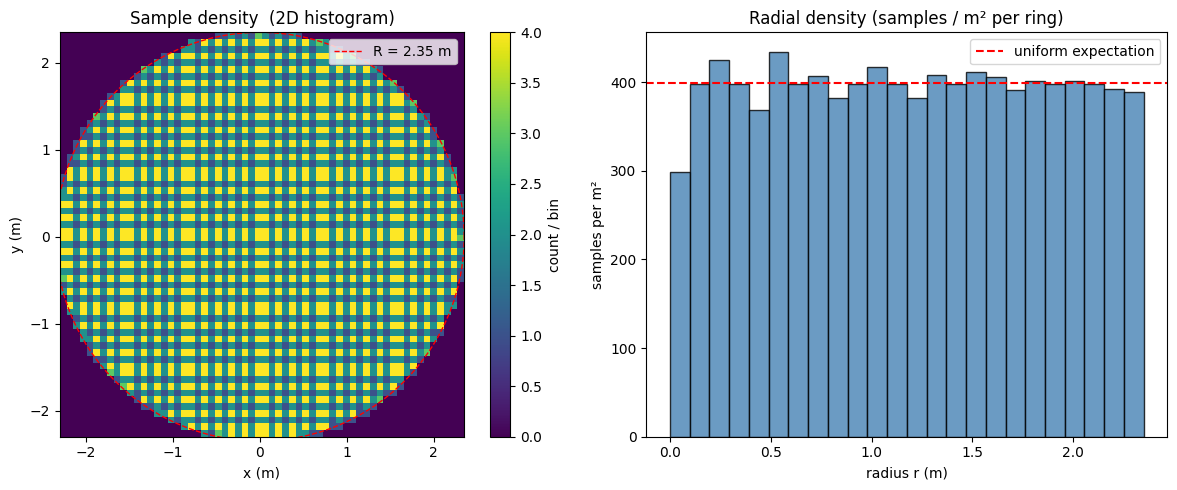

Ring-density CV (excludes empty edge): 0.061   (0 = perfectly uniform)


In [4]:
arena_radius = float(np.hypot(xy[:, 0], xy[:, 1]).max())
print(f'Arena radius (from data): R = {arena_radius:.3f} m   → area ≈ {np.pi * arena_radius**2:.2f} m²')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D histogram of (x, y)
h, xe, ye, im = axes[0].hist2d(xy[:, 0], xy[:, 1], bins=60, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_xlabel('x (m)')
axes[0].set_ylabel('y (m)')
axes[0].set_title('Sample density  (2D histogram)')
plt.colorbar(im, ax=axes[0], label='count / bin')
# outline the inferred arena boundary
theta_ring = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(arena_radius * np.cos(theta_ring), arena_radius * np.sin(theta_ring),
             color='red', lw=1.0, ls='--', label=f'R = {arena_radius:.2f} m')
axes[0].legend(loc='upper right')

# Radial density — expected constant if uniform on the disc: dN/dr ∝ r → dN/dA = const.
r  = np.hypot(xy[:, 0], xy[:, 1])
rb = np.linspace(0, arena_radius, 25)
counts, _ = np.histogram(r, bins=rb)
ring_area = np.pi * (rb[1:] ** 2 - rb[:-1] ** 2)
density   = counts / ring_area
axes[1].bar(0.5 * (rb[:-1] + rb[1:]), density,
            width=rb[1] - rb[0], edgecolor='black', color='steelblue', alpha=0.8)
axes[1].axhline(len(xy) / (np.pi * arena_radius ** 2), color='red', ls='--',
                label='uniform expectation')
axes[1].set_xlabel('radius r (m)')
axes[1].set_ylabel('samples per m²')
axes[1].set_title('Radial density (samples / m² per ring)')
axes[1].legend()

plt.tight_layout()
savefig('sampling_uniformity.png')
plt.show()

# Simple quantitative check: coefficient of variation of ring density.
cv = density.std() / density.mean()
print(f'Ring-density CV (excludes empty edge): {cv:.3f}   (0 = perfectly uniform)')

## Sweep K → per-cell field size + argmax centre, for both normalisation modes

For each `K` and each `normalize` mode: fit a fresh GMM ensemble (fits are shared
across modes because they only depend on the features, not the activation scale),
activate, and record per-cell `field_area`, `field_radius`, and `peak_xy` (the argmax
location).

In [5]:
# Fit ensembles once per K (features drive the fit; activation scale doesn't).
ensembles_by_K = {}
for K in K_VALUES:
    ensembles_by_K[K] = fit_visual_place_cells(features, n_cells=K,
                                                reg_covar=REG_COVAR,
                                                random_state=RANDOM_SEED)
    print(f'K={K:4d}  fitted')

# Activate + compute metrics under both normalisation modes.
per_cell_by_mode      = {}   # mode -> DataFrame
activations_by_mode_K = {}   # (mode, K) -> (N, K) float32

for normalize in NORMALIZE_MODES:
    label = mode_label(normalize)
    records = []
    for K in K_VALUES:
        ensemble = ensembles_by_K[K]
        act      = ensemble.activate(features, normalize=normalize)
        m        = field_metrics(act, xy, arena_radius=arena_radius)

        activations_by_mode_K[(label, K)] = act.astype(np.float32)

        fr  = m['field_radius']
        pxy = m['peak_xy']
        pv  = m['peak_value']
        ma  = m['mean_activity']

        for k in range(K):
            records.append({
                'K'            : K,
                'cell'         : k,
                'mean_activity': float(ma[k]),
                'field_area'   : float(m['field_area'][k]),
                'field_radius' : float(fr[k]),
                'peak_x'       : float(pxy[k, 0]),
                'peak_y'       : float(pxy[k, 1]),
                'peak_value'   : float(pv[k]),
            })

        print(f'  [{label:>6s}]  K={K:4d}   field_radius (m)  median={np.median(fr):.3f}  '
              f'mean={fr.mean():.3f}  IQR=[{np.quantile(fr, 0.25):.3f}, {np.quantile(fr, 0.75):.3f}]')

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(SAVE_DIR, f'per_cell_field_metrics_{label}.csv'), index=False)
    per_cell_by_mode[label] = df
    print(f'  saved per-cell metrics for mode={label!r}: {len(df)} rows\n')

K=  10  fitted


K=  20  fitted


K=  50  fitted


K= 100  fitted


K= 200  fitted


...

  [   raw]  K=  20   field_radius (m)  median=1.683  mean=1.696  IQR=[1.606, 1.792]


  [   raw]  K=  50   field_radius (m)  median=1.413  mean=1.426  IQR=[1.296, 1.520]


  [   raw]  K= 100   field_radius (m)  median=1.127  mean=1.157  IQR=[1.045, 1.258]


  [   raw]  K= 200   field_radius (m)  median=0.840  mean=0.859  IQR=[0.776, 0.929]


  [   raw]  K= 500   field_radius (m)  median=0.458  mean=0.468  IQR=[0.379, 0.534]
  saved per-cell metrics for mode='raw': 880 rows



## Summary per K

In [6]:
summary_by_mode = {}
for label, df in per_cell_by_mode.items():
    s = (df.groupby('K')
           .agg(n            =('cell',         'count'),
                mean_radius  =('field_radius', 'mean'),
                median_radius=('field_radius', 'median'),
                std_radius   =('field_radius', 'std'),
                q25_radius   =('field_radius', lambda x: x.quantile(0.25)),
                q75_radius   =('field_radius', lambda x: x.quantile(0.75)),
                min_radius   =('field_radius', 'min'),
                max_radius   =('field_radius', 'max'),
                mean_peak_val=('peak_value',   'mean'))
           .reset_index())
    s.to_csv(os.path.join(SAVE_DIR, f'field_metrics_summary_{label}.csv'), index=False)
    summary_by_mode[label] = s

    print(f'── field_radius (m) summary per K   [mode = {label}] ──')
    print(s.to_string(index=False, formatters={
        'mean_radius'  : '{:.3f}'.format,
        'median_radius': '{:.3f}'.format,
        'std_radius'   : '{:.3f}'.format,
        'q25_radius'   : '{:.3f}'.format,
        'q75_radius'   : '{:.3f}'.format,
        'min_radius'   : '{:.3f}'.format,
        'max_radius'   : '{:.3f}'.format,
        'mean_peak_val': '{:.4f}'.format,
    }))
    print()

── field_radius (m) summary per K   [mode = minmax] ──
  K   n mean_radius median_radius std_radius q25_radius q75_radius min_radius max_radius mean_peak_val
 10  10       1.808         1.795      0.056      1.777      1.851      1.718      1.906        1.0000
 20  20       1.650         1.655      0.073      1.598      1.693      1.529      1.816        1.0000
 50  50       1.403         1.403      0.115      1.325      1.490      1.140      1.592        1.0000
100 100       1.172         1.167      0.124      1.098      1.252      0.706      1.459        1.0000
200 200       0.895         0.887      0.145      0.831      0.962      0.287      1.363        1.0000
500 500       0.505         0.498      0.143      0.415      0.576      0.028      1.030        1.0000

── field_radius (m) summary per K   [mode = raw] ──
  K   n mean_radius median_radius std_radius q25_radius q75_radius min_radius max_radius mean_peak_val
 10  10       1.844         1.869      0.098      1.763      1.903  

## Distribution of field radii given K

Saved → analysis/experiment_field_size_sweep/figures/field_radius_hist_by_K.png


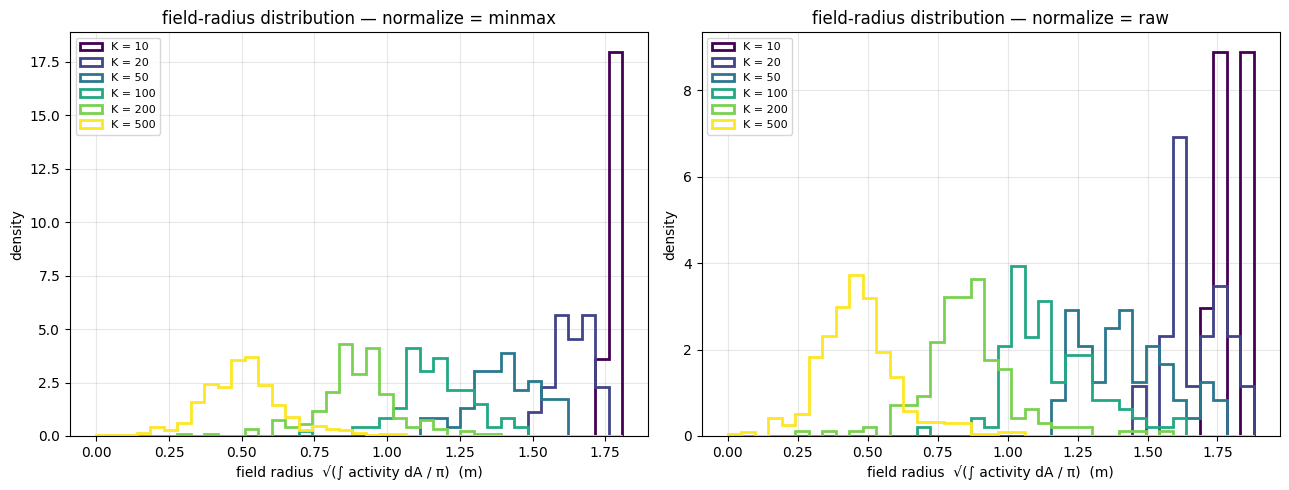

In [7]:
fig, axes = plt.subplots(1, len(NORMALIZE_MODES),
                         figsize=(6.5 * len(NORMALIZE_MODES), 5),
                         squeeze=False)

cmap = plt.get_cmap('viridis')
for col, normalize in enumerate(NORMALIZE_MODES):
    label = mode_label(normalize)
    df    = per_cell_by_mode[label]
    ax    = axes[0, col]
    bins  = np.linspace(0.0, df['field_radius'].quantile(0.995), 40)
    for i, K in enumerate(K_VALUES):
        fr = df.loc[df['K'] == K, 'field_radius'].to_numpy()
        ax.hist(fr, bins=bins, histtype='step', density=True,
                linewidth=2, color=cmap(i / max(len(K_VALUES) - 1, 1)),
                label=f'K = {K}')
    ax.set_xlabel('field radius  √(∫ activity dA / π)  (m)')
    ax.set_ylabel('density')
    ax.set_title(f'field-radius distribution — normalize = {label}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
savefig('field_radius_hist_by_K.png')
plt.show()

### Violin view — shape + spread per K

Saved → analysis/experiment_field_size_sweep/figures/field_radius_violin_by_K.png


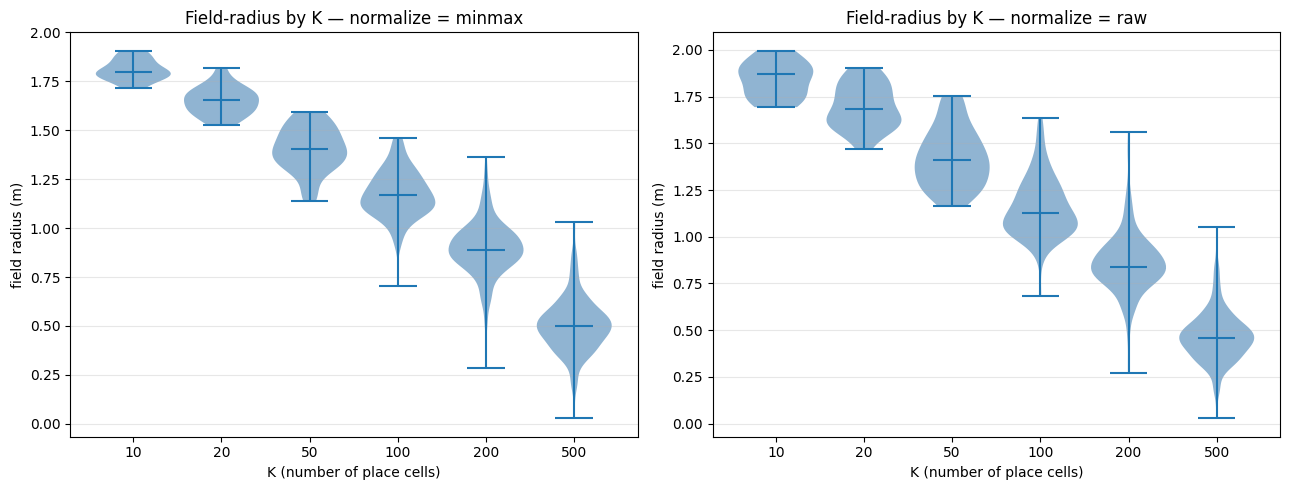

In [8]:
fig, axes = plt.subplots(1, len(NORMALIZE_MODES),
                         figsize=(6.5 * len(NORMALIZE_MODES), 5),
                         squeeze=False)

for col, normalize in enumerate(NORMALIZE_MODES):
    label = mode_label(normalize)
    df    = per_cell_by_mode[label]
    ax    = axes[0, col]
    data  = [df.loc[df['K'] == K, 'field_radius'].to_numpy() for K in K_VALUES]

    parts = ax.violinplot(data, showmedians=True, widths=0.85)
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.6)

    ax.set_xticks(range(1, len(K_VALUES) + 1))
    ax.set_xticklabels(K_VALUES)
    ax.set_xlabel('K (number of place cells)')
    ax.set_ylabel('field radius (m)')
    ax.set_title(f'Field-radius by K — normalize = {label}')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
savefig('field_radius_violin_by_K.png')
plt.show()

### Mean / median field size vs K

Saved → analysis/experiment_field_size_sweep/figures/field_radius_central_vs_K.png


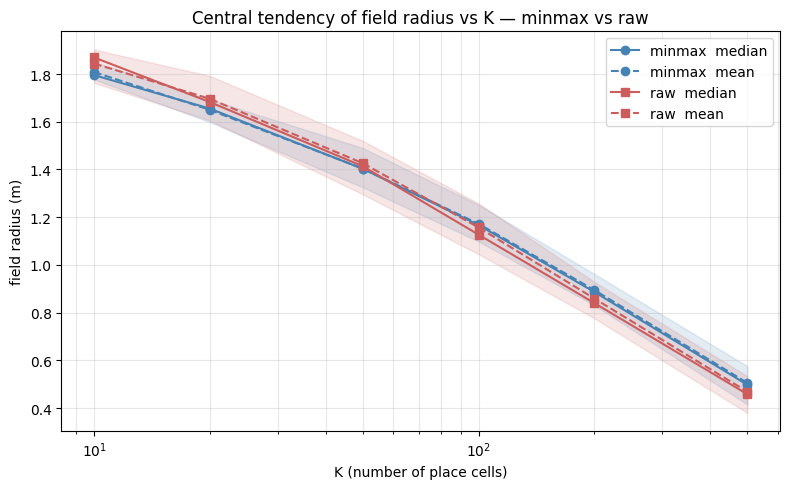

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

styles = {'minmax': dict(color='steelblue', marker='o'),
          'raw'   : dict(color='indianred', marker='s')}

for label, s in summary_by_mode.items():
    st = styles.get(label, {})
    ax.plot(s['K'], s['median_radius'], label=f'{label}  median', ls='-',  **st)
    ax.plot(s['K'], s['mean_radius'],   label=f'{label}  mean',   ls='--', **st)
    ax.fill_between(s['K'], s['q25_radius'], s['q75_radius'],
                    color=st.get('color', 'gray'), alpha=0.15)

ax.set_xscale('log')
ax.set_xlabel('K (number of place cells)')
ax.set_ylabel('field radius (m)')
ax.set_title('Central tendency of field radius vs K — minmax vs raw')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
savefig('field_radius_central_vs_K.png')
plt.show()

## Sanity check — projected activity per cell, with argmax centre + field_radius overlay

For each K we pick 6 cells spread across the `field_radius` distribution and show two versions
side by side: the min-max normalised heatmap and the raw RBF heatmap for the same cell.
Cyan `+` = argmax location; cyan dashed circle = `field_radius`.

Landmark and wall geometry parsed from `simulation/worlds/environments/vpce/circ_lm8_r0.xml`.

Wall R = 2.50 m   |   landmarks parsed: 8


Saved → analysis/experiment_field_size_sweep/figures/sanity_check_projected_activity_minmax.png


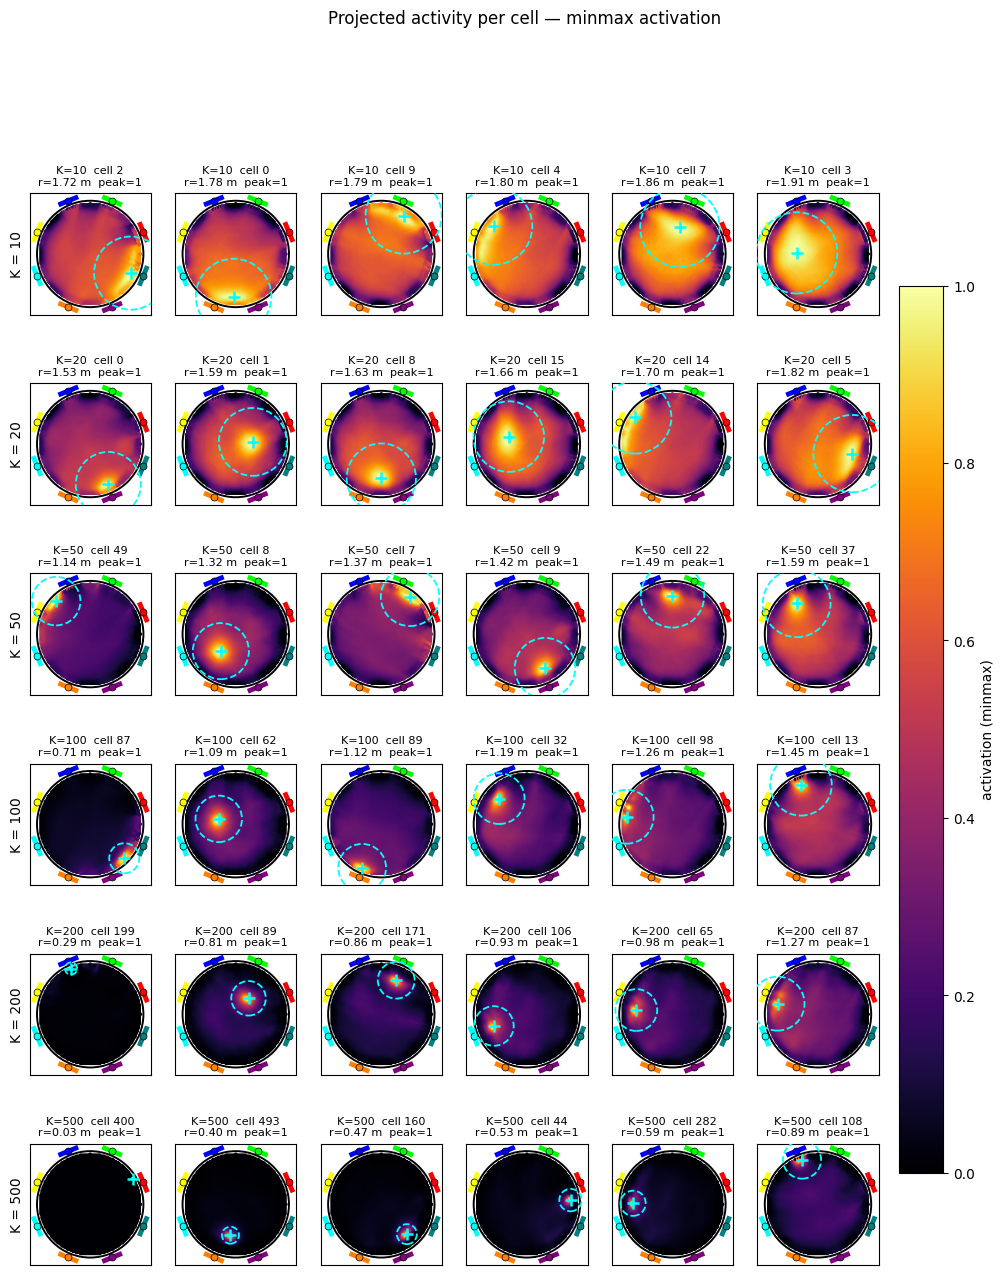

Saved → analysis/experiment_field_size_sweep/figures/sanity_check_projected_activity_raw.png


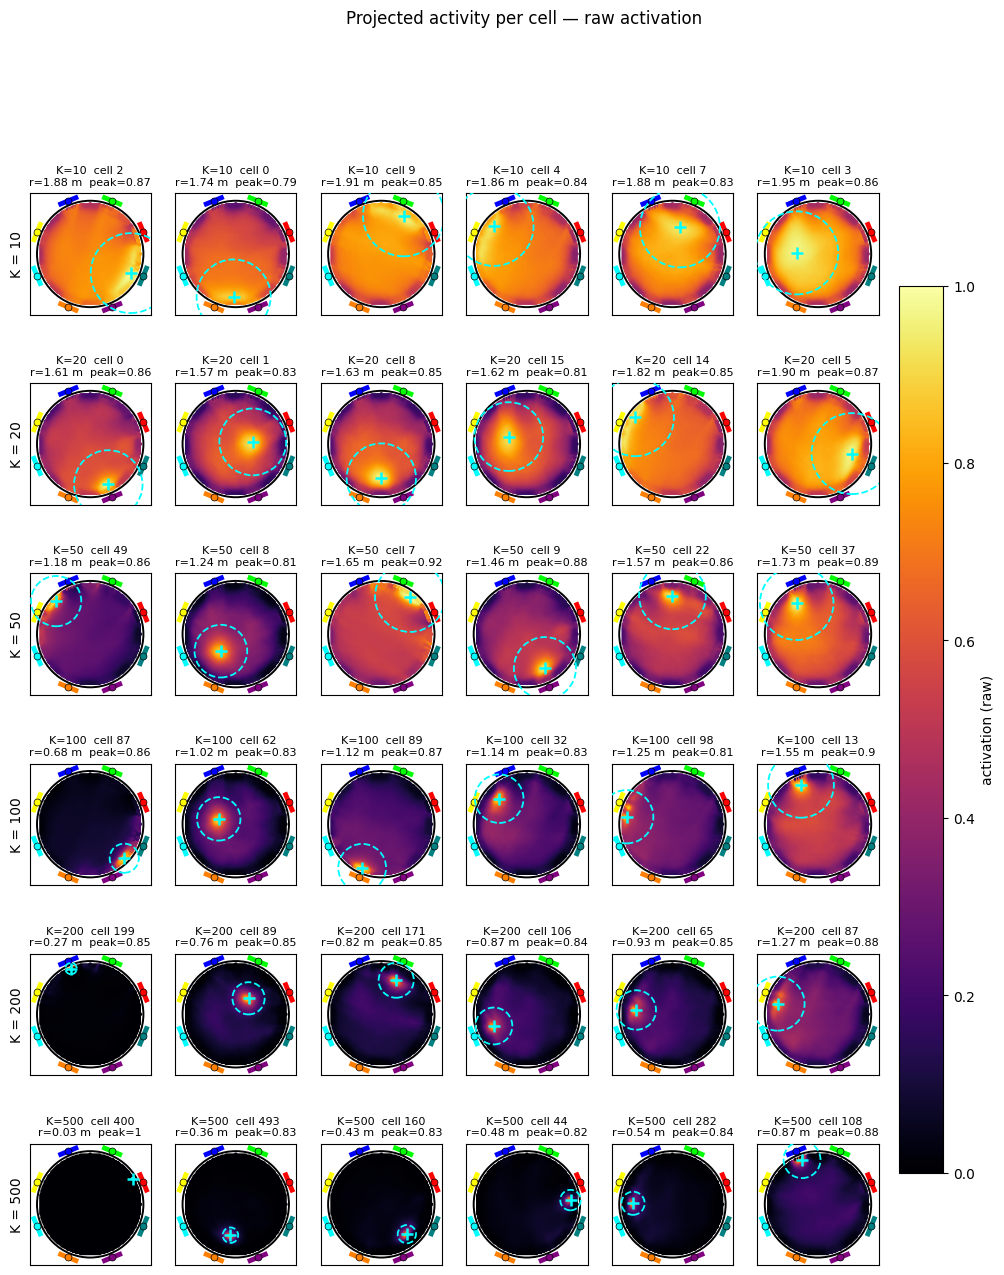

In [10]:
import xml.etree.ElementTree as ET
from matplotlib.patches import Circle

WORLD_XML = 'simulation/worlds/environments/vpce/circ_lm8_r0.xml'
tree      = ET.parse(WORLD_XML)
root      = tree.getroot()

wall_elt     = root.find('circular_wall')
wall_radius  = float(wall_elt.get('radius'))

landmarks = []
for lm in root.findall('landmark'):
    landmarks.append({
        'x'     : float(lm.get('x')),
        'y'     : float(lm.get('y')),
        'theta' : float(lm.get('theta')),
        'width' : float(lm.get('width')),
        'color' : (float(lm.get('red')), float(lm.get('green')), float(lm.get('blue'))),
    })
print(f'Wall R = {wall_radius:.2f} m   |   landmarks parsed: {len(landmarks)}')

LANDMARK_OFFSET = 0.20     # radial distance beyond wall_radius (m)
PLOT_MARGIN     = LANDMARK_OFFSET + 0.15


def _landmark_display_xy(lm):
    bearing = np.arctan2(lm['y'], lm['x'])
    r_disp  = wall_radius + LANDMARK_OFFSET
    return r_disp * np.cos(bearing), r_disp * np.sin(bearing)


def draw_environment(ax):
    """Wall + landmark panels overlaid, panels drawn just outside the wall."""
    ax.add_patch(Circle((0, 0), wall_radius,
                        fill=False, edgecolor='black', lw=1.4, zorder=3))
    for lm in landmarks:
        dx, dy = _landmark_display_xy(lm)
        tx, ty = -np.sin(lm['theta']), np.cos(lm['theta'])
        half   = lm['width'] / 2
        ax.plot([dx - half*tx, dx + half*tx], [dy - half*ty, dy + half*ty],
                color=lm['color'], lw=3.5, solid_capstyle='butt', zorder=4)
        ax.plot(dx, dy, marker='o', color=lm['color'], markersize=5,
                markeredgecolor='black', markeredgewidth=0.5, zorder=5)


N_SHOW      = 6
rank_quants = np.linspace(0.0, 0.99, N_SHOW)

# For each K, pick cells by rank on the MINMAX field_radius so cell IDs are the same
# in both mode panels (fits are shared — the cell IDs mean the same thing across modes).
picked_by_K = {}
for K in K_VALUES:
    df_K = per_cell_by_mode['minmax'][per_cell_by_mode['minmax']['K'] == K] \
              .sort_values('field_radius').reset_index(drop=True)
    idxs   = np.clip(np.round(rank_quants * (len(df_K) - 1)).astype(int), 0, len(df_K) - 1)
    picked_by_K[K] = df_K.iloc[idxs]['cell'].to_numpy()


for normalize in NORMALIZE_MODES:
    label = mode_label(normalize)
    fig, axes = plt.subplots(len(K_VALUES), N_SHOW,
                             figsize=(2.2 * N_SHOW, 2.4 * len(K_VALUES)),
                             squeeze=False)

    df_mode = per_cell_by_mode[label]
    sc = None
    for row, K in enumerate(K_VALUES):
        act_K   = activations_by_mode_K[(label, K)]
        picked  = picked_by_K[K]
        vmin, vmax = 0.0, float(act_K.max())

        for col, k in enumerate(picked):
            k    = int(k)
            row_df = df_mode[(df_mode['K'] == K) & (df_mode['cell'] == k)].iloc[0]
            fr   = float(row_df['field_radius'])
            px   = float(row_df['peak_x'])
            py   = float(row_df['peak_y'])
            pv   = float(row_df['peak_value'])
            ak   = act_K[:, k]

            ax = axes[row, col]
            sc = ax.scatter(xy[:, 0], xy[:, 1], c=ak, s=3,
                            cmap='inferno', vmin=vmin, vmax=vmax, zorder=2)
            draw_environment(ax)

            ax.add_patch(Circle((px, py), fr,
                                fill=False, edgecolor='cyan', lw=1.3, ls='--', zorder=7))
            ax.plot(px, py, marker='+', color='cyan', markersize=9,
                    markeredgewidth=1.8, zorder=8)

            lim = wall_radius + PLOT_MARGIN
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.set_aspect('equal')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'K={K}  cell {k}\nr={fr:.2f} m  peak={pv:.2g}', fontsize=8)

            if col == 0:
                ax.set_ylabel(f'K = {K}', fontsize=10)

    cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8, pad=0.02)
    cbar.set_label(f'activation ({label})')

    fig.suptitle(f'Projected activity per cell — {label} activation',
                 fontsize=12, y=0.995)
    savefig(f'sanity_check_projected_activity_{label}.png')
    plt.show()

## Receptive field map per K — argmax centre + field_radius, per mode

Every cell as a circle: centre = argmax `(x, y)` (highest activation across the sampled
population), radius = `field_radius`. One figure per normalisation mode.

Saved → analysis/experiment_field_size_sweep/figures/receptive_field_map_by_K_minmax.png


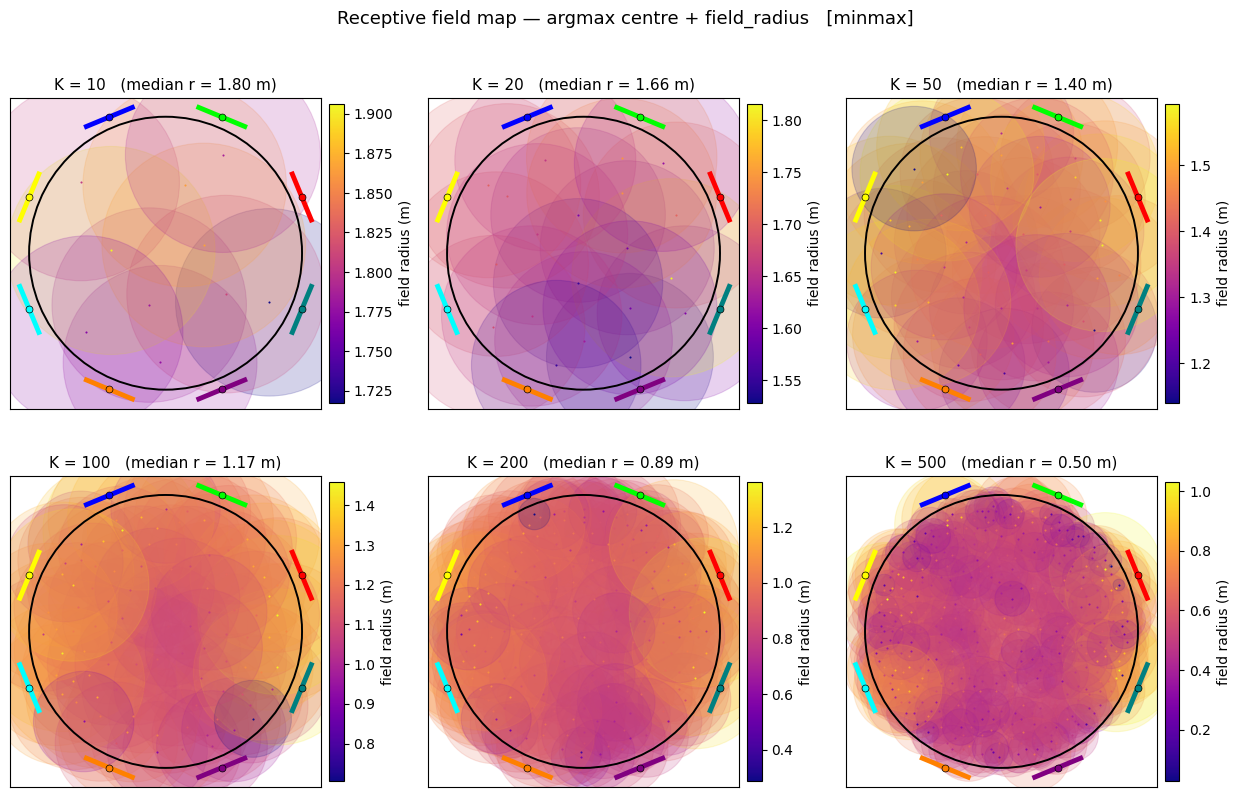

Saved → analysis/experiment_field_size_sweep/figures/receptive_field_map_by_K_raw.png


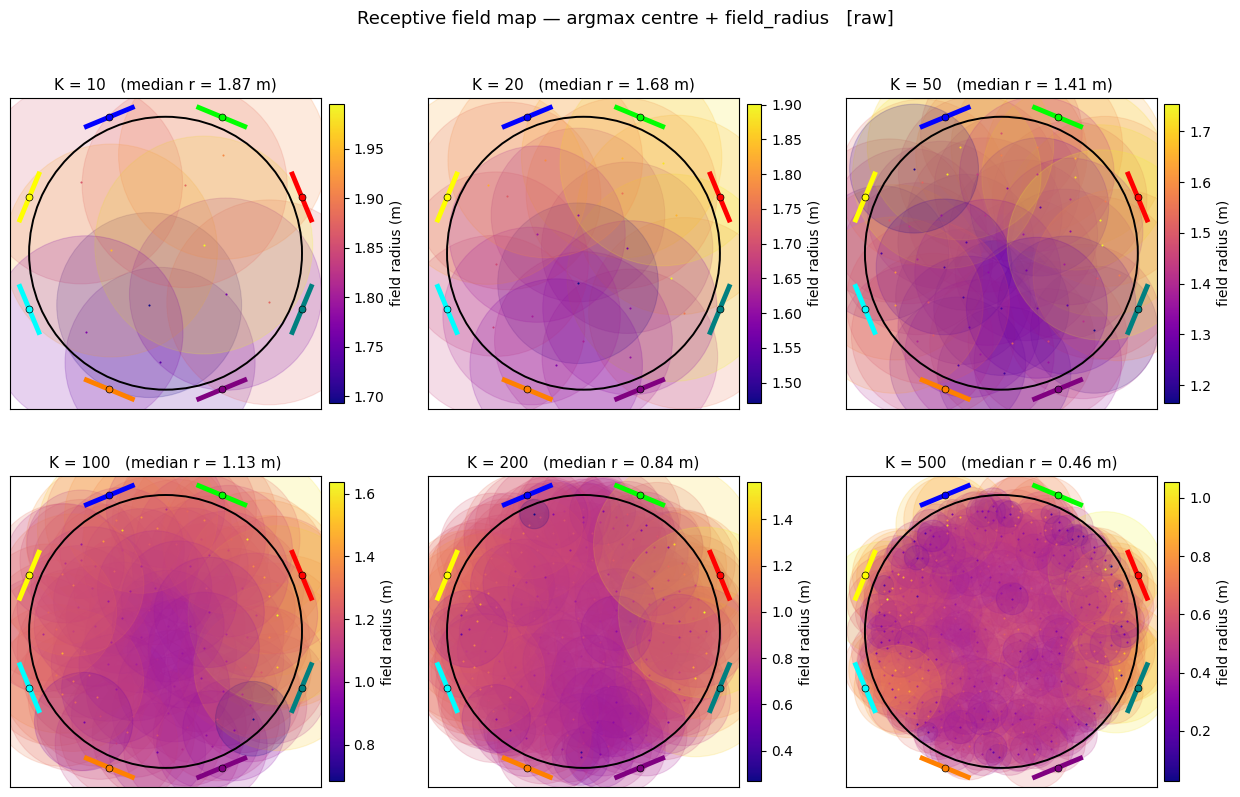

In [11]:
n_cols = 3
n_rows = int(np.ceil(len(K_VALUES) / n_cols))

for normalize in NORMALIZE_MODES:
    label = mode_label(normalize)
    df    = per_cell_by_mode[label]

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.2 * n_cols, 4.2 * n_rows),
                             squeeze=False)

    for idx, K in enumerate(K_VALUES):
        ax   = axes[idx // n_cols, idx % n_cols]
        dK   = df[df['K'] == K].sort_values('cell').reset_index(drop=True)
        fr   = dK['field_radius'].to_numpy()
        cx   = dK['peak_x'].to_numpy()
        cy   = dK['peak_y'].to_numpy()

        norm = mpl.colors.Normalize(vmin=fr.min(), vmax=fr.max())
        cmap = plt.get_cmap('plasma')

        draw_environment(ax)
        for xk, yk, r, colour in zip(cx, cy, fr, cmap(norm(fr))):
            ax.add_patch(Circle((xk, yk), r,
                                facecolor=colour, edgecolor=colour,
                                alpha=0.18, lw=0.8, zorder=2))
            ax.plot(xk, yk, marker='.', color=colour, markersize=3,
                    markeredgewidth=0, zorder=6)

        lim = wall_radius + PLOT_MARGIN
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'K = {K}   (median r = {np.median(fr):.2f} m)', fontsize=11)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.02, label='field radius (m)')

    for idx in range(len(K_VALUES), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')

    fig.suptitle(f'Receptive field map — argmax centre + field_radius   [{label}]',
                 fontsize=13, y=0.995)
    plt.tight_layout()
    savefig(f'receptive_field_map_by_K_{label}.png')
    plt.show()